In [1]:
# Install the library
!pip install -U ultralytics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.6 MB/s eta 0:00:0000:0100:01


In [2]:
import os
import glob
import cv2
import torch
from PIL import Image
import pandas as pd
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


**Clean up of Dataset**
The dataset contains images of bananas with image size 640 x 320 .There are 188 images in train and test. The images are noisy and the model would struggle to generalise the banana patterns. so I am using YOLO to find the banana in each image and crop the photo so that only the banana remains. By cropping to the banana, I am increasing the "Signal-to-Noise Ratio" for the ResNet-18 pretrained model. If YOLO fails to detect the banana, it falls back to a simple center crop of size 320 x320. 
This code is an "Ensemble Preprocessor" which uses two different logic paths—Deep Learning (YOLO) and Heuristic (Center Crop)—to ensure all images are ready for the ResNet-18 model.

In [ ]:
# 1. Initialize yolo v8m Model
detector = YOLO('yolov8m.pt')

def get_center_crop(img, target_size=320):
    """
    Fallback Heuristic: Extracts a square from the center of the image.
    Used when YOLO fails to detect a banana .
    """
    h, w = img.shape[:2]
    
    # Safety check: if image is smaller than target, resize it instead of cropping
    if h < target_size or w < target_size:
        return cv2.resize(img, (target_size, target_size))

    # Calculate coordinates to keep the crop perfectly centered horizontally
    start_x = w // 2 - target_size // 2
    # Vertical height is 320, so start_y will be 0, capturing the full height
    start_y = h // 2 - target_size // 2
    
    return img[start_y:start_y+target_size, start_x:start_x+target_size]

def process_dataset(input_root, output_root):
    """
    Main Pipeline: Iterates through varieties, detects/crops, and saves.
    """
    print(f"\n Starting processing: {input_root}")
    
    # Find all variety folders (e.g., 'redbanana', 'silkbanana')
    subfolders = glob.glob(os.path.join(input_root, '*'))
    
    for folder in subfolders:
        class_name = os.path.basename(folder)
        output_dir = os.path.join(output_root, class_name)
        
        # Create output class folder if it doesn't exist
        os.makedirs(output_dir, exist_ok=True)

        # Process every JPG image in the variety folder
        images = glob.glob(os.path.join(folder, '*.jpg'))
        for img_path in images:
            img_name = os.path.basename(img_path)
            img = cv2.imread(img_path)
            if img is None: continue # Skip corrupted files

            # Step 1: Attempt AI Detection
            # Banana = Class 46 in COCO. Using conf=0.1 to catch low-confidence black bananas.
            results = detector(img_path, conf=0.1, verbose=False)
            found_banana = False
            
            for result in results:
                for box in result.boxes:
                    if int(box.cls) == 46:
                        # Extract bounding box coordinates (x1, y1, x2, y2)
                        x1, y1, x2, y2 = map(int, box.xyxy[0])
                        
                        # Snip the banana out of the original image
                        crop = img[y1:y2, x1:x2]
                        cv2.imwrite(os.path.join(output_dir, img_name), crop)
                        found_banana = True
                        break # Only take the first/best banana detected
                if found_banana: break

            # Step 2: Apply Fallback if AI detection failed
            if not found_banana:
                # Capture the 320x320 center (Standardized for 640x320 inputs)
                crop = get_center_crop(img, target_size=320)
                cv2.imwrite(os.path.join(output_dir, img_name), crop)
                print(f"  Fallback (Center Crop): {class_name}/{img_name}")

    print(f"Finished: {output_root}")

# --- Kaggle Environment Path Configuration ---
# Input: Read-only dataset source
train_input = '/kaggle/input/datasets/andrewblur/banana-rotting-dataset/banana_dataset/train'
test_input = '/kaggle/input/datasets/andrewblur/banana-rotting-dataset/banana_dataset/test'

# Output: Writable working directory for cleaned/cropped images
train_output = '/kaggle/working/banana_dataset_cropped/train'
test_output = '/kaggle/working/banana_dataset_cropped/test'

# Run the full end-to-end pipeline
process_dataset(train_input, train_output)
process_dataset(test_input, test_output)

print("\n Full Preprocessing Pipeline Complete!")

In [ ]:
# # 1. Initialize Model and Settings
# detector = YOLO('yolov8m.pt')

# def get_center_crop(img, target_size=320):
#     h, w = img.shape[:2]
#     if h < target_size or w < target_size:
#         return cv2.resize(img, (target_size, target_size))

#     start_x = w // 2 - target_size // 2
#     start_y = h // 2 - target_size // 2
#     return img[start_y:start_y+target_size, start_x:start_x+target_size]

# def process_dataset(input_root, output_root):
#     print(f"\n Starting processing: {input_root}")
#     subfolders = glob.glob(os.path.join(input_root, '*'))
    
#     for folder in subfolders:
#         class_name = os.path.basename(folder)
#         output_dir = os.path.join(output_root, class_name)
#         os.makedirs(output_dir, exist_ok=True)

#         images = glob.glob(os.path.join(folder, '*.jpg'))
#         for img_path in images:
#             img_name = os.path.basename(img_path)
#             img = cv2.imread(img_path)
#             if img is None: continue

#             # Try YOLO detection (Banana = Class 46)
#             results = detector(img_path, conf=0.1, verbose=False)
#             found_banana = False
            
#             for result in results:
#                 for box in result.boxes:
#                     if int(box.cls) == 46:
#                         x1, y1, x2, y2 = map(int, box.xyxy[0])
#                         crop = img[y1:y2, x1:x2]
#                         cv2.imwrite(os.path.join(output_dir, img_name), crop)
#                         found_banana = True
#                         break
#                 if found_banana: break

#             # --- FALLBACK ---
#             if not found_banana:
#                 crop = get_center_crop(img, target_size=320)
#                 cv2.imwrite(os.path.join(output_dir, img_name), crop)
#                 print(f"  Fallback (Center Crop): {class_name}/{img_name}")

#     print(f"Finished: {output_root}")

# # 2. Define Kaggle Paths
# train_input = '/kaggle/input/datasets/andrewblur/banana-rotting-dataset/banana_dataset/train'
# train_output = '/kaggle/working/banana_dataset_cropped/train'

# test_input = '/kaggle/input/datasets/andrewblur/banana-rotting-dataset/banana_dataset/test'
# test_output = '/kaggle/working/banana_dataset_cropped/test'

# # 3. Run the Pipeline
# process_dataset(train_input, train_output)
# process_dataset(test_input, test_output)

# print("\n Full Preprocessing Pipeline Complete!")

In [39]:
# detector = YOLO('yolov8m.pt')
# base_path = '/kaggle/input/datasets/andrewblur/banana-rotting-dataset/banana_dataset/train'
# output_base = '/kaggle/working/banana_dataset_cropped/train'

# def get_center_crop(img, target_size=320):
#     h, w = img.shape[:2]
#     # If the image is smaller than 320, we just return the original
#     if h < target_size or w < target_size:
#         return cv2.resize(img, (target_size, target_size))

#     start_x = w // 2 - target_size // 2
#     start_y = h // 2 - target_size // 2
#     return img[start_y:start_y+target_size, start_x:start_x+target_size]

# subfolders = glob.glob(os.path.join(base_path, '*'))

# for folder in subfolders:
#     class_name = os.path.basename(folder)
#     output_dir = os.path.join(output_base, class_name)
#     os.makedirs(output_dir, exist_ok=True)

#     images = glob.glob(os.path.join(folder, '*.jpg'))
#     for img_path in images:
#         img_name = os.path.basename(img_path)
#         img = cv2.imread(img_path)
#         if img is None: continue

#         # Try YOLO  with a confidence threshold 0.1
#         results = detector(img_path, conf=0.1, verbose=False)

#         found_banana = False
#         for result in results:
#             for box in result.boxes:
#                 if int(box.cls) == 46: # 46 is banana
#                     x1, y1, x2, y2 = map(int, box.xyxy[0])
#                     crop = img[y1:y2, x1:x2]
#                     cv2.imwrite(os.path.join(output_dir, img_name), crop)
#                     found_banana = True
#                     break
#             if found_banana: break

#         # --- FALLBACK ---
#         if not found_banana:
#             # If YOLO fails, do a Center Crop to capture the middle
#             crop = get_center_crop(img, target_size=320)
#             cv2.imwrite(os.path.join(output_dir, img_name), crop)
#             print(f"Fallback: Center Cropped {img_name} (Class: {class_name})")

# print("\n Processing complete.")

Fallback: Center Cropped silkbanana_3_8.jpg (Class: silkbanana)
Fallback: Center Cropped pomebanana_4_8.jpg (Class: pomebanana)
Fallback: Center Cropped nendranbanana_2_8.jpg (Class: nendranbanana)
Fallback: Center Cropped nendranbanana_3_8.jpg (Class: nendranbanana)
Fallback: Center Cropped nendranbanana_4_6.jpg (Class: nendranbanana)
Fallback: Center Cropped nendranbanana_4_8.jpg (Class: nendranbanana)
Fallback: Center Cropped neypoovanbanana_3_8.jpg (Class: neypoovanbanana)
Fallback: Center Cropped redbanana_3_1.jpg (Class: redbanana)
Fallback: Center Cropped redbanana_3_2.jpg (Class: redbanana)
Fallback: Center Cropped honeybanana_4_6.jpg (Class: honeybanana)
Fallback: Center Cropped honeybanana_4_4.jpg (Class: honeybanana)
Fallback: Center Cropped honeybanana_4_7.jpg (Class: honeybanana)
Fallback: Center Cropped honeybanana_2_7.jpg (Class: honeybanana)

 Processing complete.


In [40]:
# # 1. Initialize YOLO
# detector = YOLO('yolov8m.pt') 

# # 2. Define Paths
# base_path = '/kaggle/input/datasets/andrewblur/banana-rotting-dataset/banana_dataset/train'
# output_base = '/kaggle/working/banana_dataset_cropped/train'

# # 3. Get all subfolders (classes)
# subfolders = glob.glob(os.path.join(base_path, '*'))

# for folder in subfolders:
#     class_name = os.path.basename(folder)
#     output_dir = os.path.join(output_base, class_name)
#     os.makedirs(output_dir, exist_ok=True)
    
#     print(f"Processing class: {class_name}...")
    
#     # Get all jpg images in this class folder
#     images = glob.glob(os.path.join(folder, '*.jpg'))
    
#     for img_path in images:
#         img_name = os.path.basename(img_path)
        
#         # Run YOLO inference
#         results = detector(img_path, conf=0.1) # 0.3 threshold is usually safe
        
#         # Check if we found anything
#         found_banana = False
#         for result in results:
#             for box in result.boxes:
#                 # Class 46 is 'banana' in COCO dataset
#                 if int(box.cls) == 46:
#                     x1, y1, x2, y2 = map(int, box.xyxy[0])
                    
#                     # Read and crop
#                     img = cv2.imread(img_path)
#                     if img is not None:
#                         crop = img[y1:y2, x1:x2]
                        
#                         # Save to new "clean" directory
#                         cv2.imwrite(os.path.join(output_dir, img_name), crop)
#                         found_banana = True
#                     break # Stop after the first banana detected
#             if found_banana: break
            
#         if not found_banana:
#             print(f"⚠️ No banana detected in {img_name}. Skipping...")

# print("\n Cropping complete! Check your new folder: ./banana_dataset_cropped/train")

In [41]:
# base_path = '/kaggle/input/datasets/andrewblur/banana-rotting-dataset/banana_dataset/test'
# output_base = '/kaggle/working/banana_dataset_cropped/test'

# def get_center_crop(img, target_size=320):
#     h, w = img.shape[:2]
#     # If the image is smaller than 320, we just return the original
#     if h < target_size or w < target_size:
#         return cv2.resize(img, (target_size, target_size))

#     start_x = w // 2 - target_size // 2
#     start_y = h // 2 - target_size // 2
#     return img[start_y:start_y+target_size, start_x:start_x+target_size]

# subfolders = glob.glob(os.path.join(base_path, '*'))

# for folder in subfolders:
#     class_name = os.path.basename(folder)
#     output_dir = os.path.join(output_base, class_name)
#     os.makedirs(output_dir, exist_ok=True)

#     images = glob.glob(os.path.join(folder, '*.jpg'))
#     for img_path in images:
#         img_name = os.path.basename(img_path)
#         img = cv2.imread(img_path)
#         if img is None: continue

#         # Try YOLO first with a very low confidence threshold (0.1)
#         results = detector(img_path, conf=0.1, verbose=False)

#         found_banana = False
#         for result in results:
#             for box in result.boxes:
#                 if int(box.cls) == 46: # 46 is banana
#                     x1, y1, x2, y2 = map(int, box.xyxy[0])
#                     crop = img[y1:y2, x1:x2]
#                     cv2.imwrite(os.path.join(output_dir, img_name), crop)
#                     found_banana = True
#                     break
#             if found_banana: break

#         # --- FALLBACK ---
#         if not found_banana:
#             # If YOLO fails, do a Center Crop to capture the middle
#             crop = get_center_crop(img, target_size=320)
#             cv2.imwrite(os.path.join(output_dir, img_name), crop)
#             print(f"Fallback: Center Cropped {img_name} (Class: {class_name})")

# print("\n Processing complete.")

Fallback: Center Cropped pomebanana_2_8.jpg (Class: pomebanana)
Fallback: Center Cropped nendranbanana_2_8.jpg (Class: nendranbanana)
Fallback: Center Cropped nendranbanana_3_8.jpg (Class: nendranbanana)
Fallback: Center Cropped nendranbanana_3_7.jpg (Class: nendranbanana)
Fallback: Center Cropped nendranbanana_1_8.jpg (Class: nendranbanana)
Fallback: Center Cropped redbanana_4_1.jpg (Class: redbanana)
Fallback: Center Cropped honeybanana_3_6.jpg (Class: honeybanana)
Fallback: Center Cropped honeybanana_3_4.jpg (Class: honeybanana)
Fallback: Center Cropped honeybanana_3_5.jpg (Class: honeybanana)

 Processing complete.


In [42]:
# # 2. Define Paths
# base_path = '/kaggle/input/datasets/andrewblur/banana-rotting-dataset/banana_dataset/test'
# output_base = '/kaggle/working/banana_dataset_cropped/test'

# # 3. Get all subfolders (classes)
# subfolders = glob.glob(os.path.join(base_path, '*'))

# for folder in subfolders:
#     class_name = os.path.basename(folder)
#     output_dir = os.path.join(output_base, class_name)
#     os.makedirs(output_dir, exist_ok=True)
    
#     print(f"Processing class: {class_name}...")
    
#     # Get all jpg images in this class folder
#     images = glob.glob(os.path.join(folder, '*.jpg'))
    
#     for img_path in images:
#         img_name = os.path.basename(img_path)
        
#         # Run YOLO inference
#         results = detector(img_path, conf=0.1) # 0.3 threshold is usually safe
        
#         # Check if we found anything
#         found_banana = False
#         for result in results:
#             for box in result.boxes:
#                 # Class 46 is 'banana' in COCO dataset
#                 if int(box.cls) == 46:
#                     x1, y1, x2, y2 = map(int, box.xyxy[0])
                    
#                     # Read and crop
#                     img = cv2.imread(img_path)
#                     if img is not None:
#                         crop = img[y1:y2, x1:x2]
                        
#                         # Save to new "clean" directory
#                         cv2.imwrite(os.path.join(output_dir, img_name), crop)
#                         found_banana = True
#                     break # Stop after the first banana detected
#             if found_banana: break
            
#         if not found_banana:
#             print(f" No banana detected in {img_name}. Skipping...")

# print("\n Cropping complete! Check your new folder: ./banana_dataset_cropped/test")

In [43]:
# 1. Create the TRAIN DataFrame
train_paths = glob.glob('/kaggle/working/banana_dataset_cropped/train/*/*.jpg')
train_data = []

for p in train_paths:
    filename = os.path.basename(p)
    # Extracts the day (e.g., 'redbanana_1_8.jpg' -> 8.0)
    label = float(filename.split('_')[-1].split('.')[0])
    train_data.append({'filepath': p, 'label': label})

train_df = pd.DataFrame(train_data)

In [44]:
# 2. Create the TEST DataFrame
test_paths = glob.glob('/kaggle/working/banana_dataset_cropped/test/*/*.jpg')

test_data = []

for p in test_paths:
    filename = os.path.basename(p)
    label = float(filename.split('_')[-1].split('.')[0])
    test_data.append({'filepath': p, 'label': label})

test_df = pd.DataFrame(test_data)

print(f"Train DF created with {len(train_df)} images.")
print(f"Test DF created with {len(test_df)} images.")

Train DF created with 188 images.
Test DF created with 188 images.


In [45]:
train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=42)

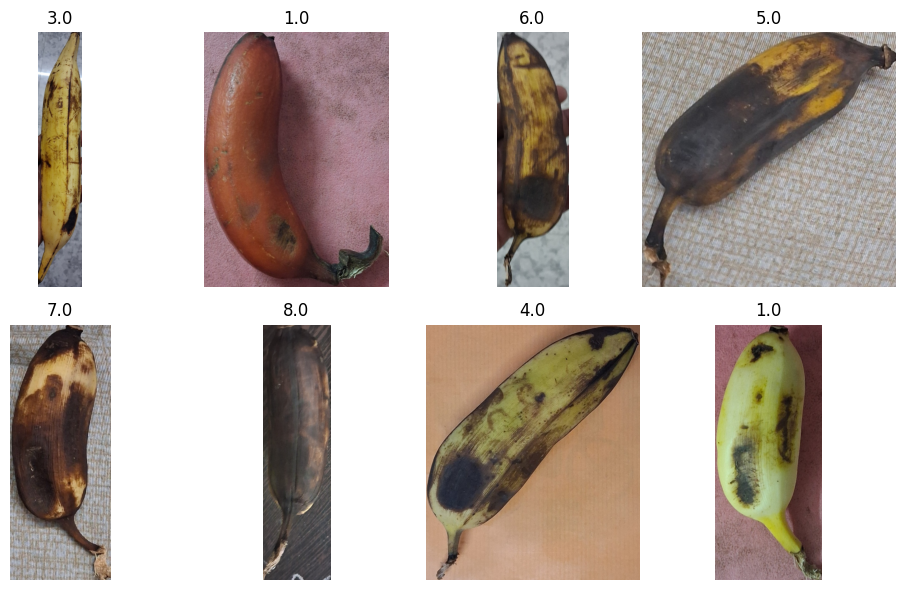

In [46]:
fig, axs = plt.subplots(2,4,figsize=(10,6))
axs_flat = axs.flatten()
for i, ax in enumerate(axs_flat):
  img = Image.open(train_df['filepath'].iloc[i])
  label = train_df['label'].iloc[i]
  ax.imshow(img)
  ax.set_title(label)
  ax.axis('off')

plt.tight_layout()
plt.show()

In [47]:
# ImageNet normalization is standard for EfficientNet
train_transform = transforms.Compose([
    # transforms.Resize((224,224)), # Bring the image closer
    # transforms.CenterCrop((180,180)), # Crop tighter to exclude the edges/hands
    transforms.Resize((224,224)), # Resize back to what ResNet-18 expects
    transforms.RandomHorizontalFlip(), # Basic augmentation for better accuracy
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ImageNet normalization is standard for EfficientNet
test_transform = transforms.Compose([
    # transforms.Resize(((256, 256))),
    # transforms.CenterCrop((180,180)), # Crop tighter to exclude the edges/hands
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [48]:
class BananaRegressionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # .iloc[idx, col_index] is the standard way to get a value by position
        img_path = self.dataframe.iloc[idx, 0]
        image = Image.open(img_path).convert("RGB")

        # Pulling the label and converting to tensor for Regression
        label_val = self.dataframe.iloc[idx, 1]
        label = torch.tensor([label_val], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label

In [49]:
# 1. Define the Datasets
train_set = BananaRegressionDataset(train_df, transform=train_transform)
val_set = BananaRegressionDataset(val_df, transform=test_transform)
test_set = BananaRegressionDataset(test_df, transform=test_transform)

# 2. Define the DataLoaders (This is where shuffle goes!)
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_set,
    batch_size=32,
    shuffle=True  # Shuffle training data to help the model generalize
)
val_loader = DataLoader(
    val_set,
    batch_size=32,
    shuffle=False  # Shuffle training data to help the model generalize
)
test_loader = DataLoader(
    test_set,
    batch_size=32,
    shuffle=False # No need to shuffle test data; we just want to evaluate it
)

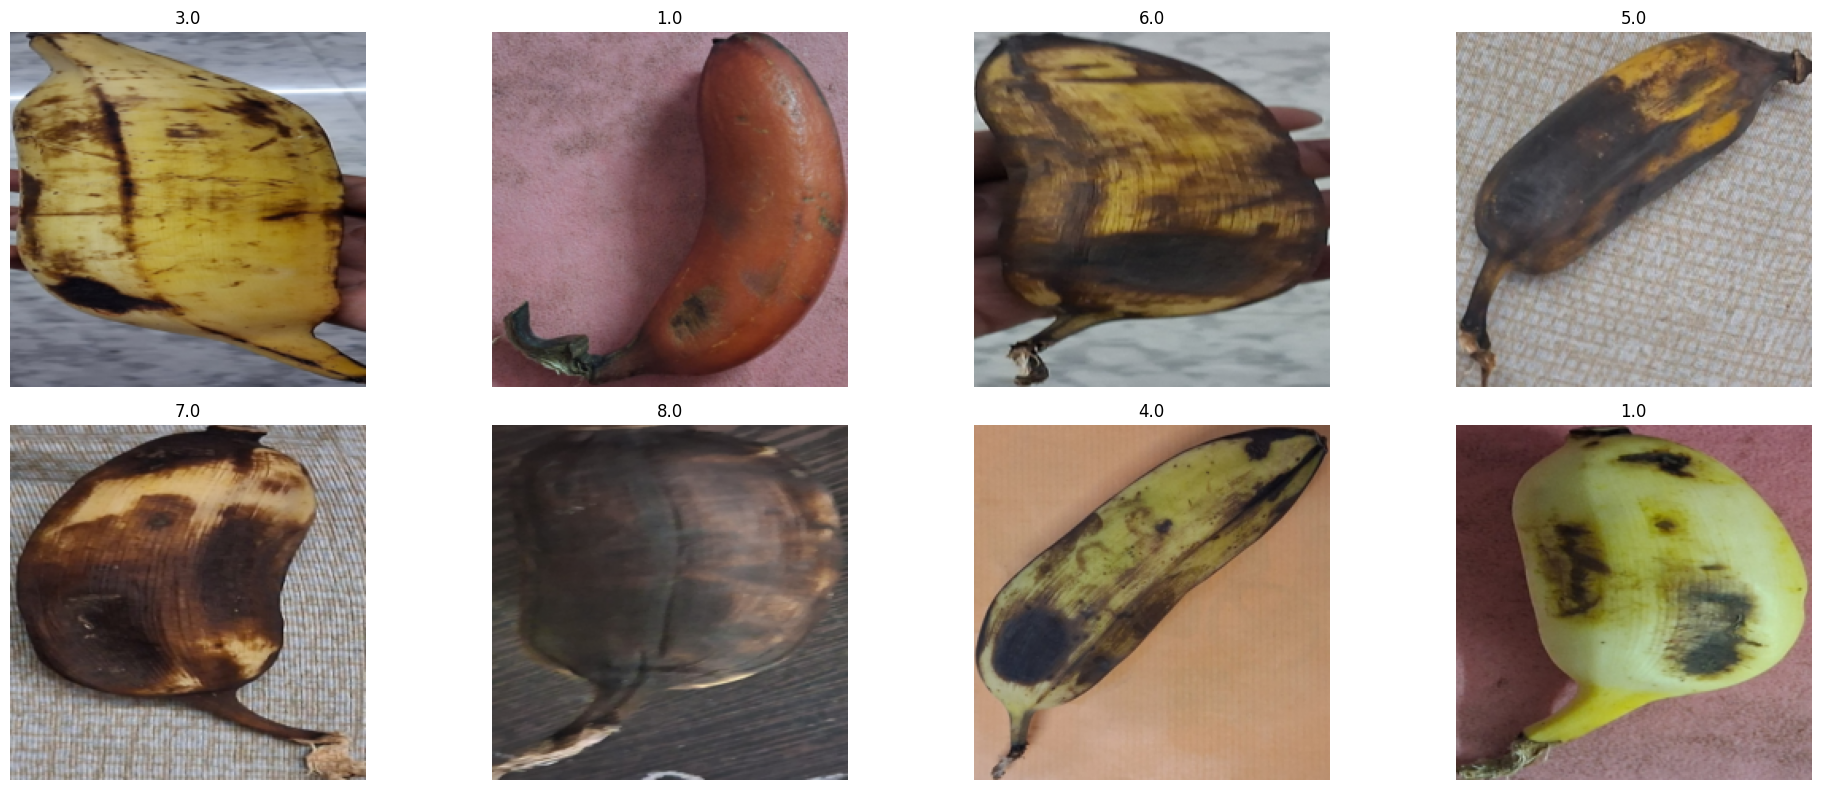

In [50]:
# Initialize a grid of 2 rows and 4 columns for a total of 8 preview images.
fig, axs = plt.subplots(2, 4, figsize=(20, 8))

# Flatten the 2D axes array into 1D so we can iterate through it with a single index.
axs_flat = axs.flatten()

# Loop through the subplots and pull the first 8 items from the train_set.
for i, ax in enumerate(axs_flat):
    # Pull the transformed image tensor and integer label from our CustomImageDataset.
    img_tensor, label = train_set[i]

    # Reorder dimensions: PyTorch (Channel, Height, Width) to NumPy (Height, Width, Channel).
    # Matplotlib's imshow requires the color channel to be the last dimension.
    img_np = img_tensor.permute(1, 2, 0).numpy()

    # Define the ImageNet statistics used in the earlier normalization step.
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # Reverse the normalization: image = (z * std) + mean.
    # This restores the original color distribution for human viewing.
    img_np = (img_np * std) + mean

    # Ensure all pixel values are between 0 and 1 to prevent visual artifacts or errors.
    img_np = np.clip(img_np, 0, 1)

    # Plot the restored image.
    ax.imshow(img_np)

    # Remove coordinate axes for a cleaner gallery-style presentation.
    ax.axis('off')

    # Label each image with its corresponding class name.
    ax.set_title(label.item())

# Automatically adjust subplot parameters to give each image enough breathing room.
plt.tight_layout()

# Display the final plot.
plt.show()

In [51]:
# from torchvision import models
# #Initialize resnet-18
# model = models.resnet18(weights='DEFAULT')

# #Modify for Regression (ResNet uses .fc instead of .classifier)
# in_features = model.fc.in_features
# model.fc = torch.nn.Linear(in_features, 1)

# # Freeze everything except the regression head
# for param in model.parameters():
#     param.requires_grad = False

# for param in model.fc.parameters():
#     param.requires_grad = True

# optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.1)

In [52]:
from torchvision import models

# 1. Initialize ResNet-18
model = models.resnet18(weights='DEFAULT')

# 2. Modify for Regression (ResNet uses .fc instead of .classifier)
in_features = model.fc.in_features
model.fc = torch.nn.Linear(in_features, 1)

# 3. Freeze everything
for param in model.parameters():
    param.requires_grad = False

# 4. Selective Unfreeze: Unfreeze the last block (layer4) and the new head
# ResNet-18 is divided into layer1, layer2, layer3, layer4
for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

# 5. Optimizer (only for trainable parameters)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.1)

In [53]:
# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [54]:
# optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
criterion = torch.nn.MSELoss() # Best for regression


# Move the loop OUTSIDE the function
def train_loop(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Calculate average loss for the WHOLE epoch
    epoch_loss = running_loss / len(loader)
    return epoch_loss

def val_loop(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    total_mae = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels) # This is your MSE

            running_loss += loss.item()
            total_mae += torch.abs(outputs - labels).sum().item()

            # Collect all for R2 calculation
            all_preds.extend(outputs.view(-1).cpu().tolist())
            all_labels.extend(labels.view(-1).cpu().tolist())

    # Metrics Calculation
    avg_mse = running_loss / len(loader)
    avg_mae = total_mae / len(loader.dataset)

    # Coefficient of Determination (R2 Score)
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2_score = 1 - (ss_res / ss_tot)

    return avg_mse, avg_mae, r2_score

# --- The Main Training Loop ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [55]:
EPOCHS = 50
best_val_loss = float('inf')  # Track the best VALIDATION loss, not train

# Initialize lists to store metrics for plotting
history = {
    'train_loss': [],
    'val_mse': [],
    'val_mae': [],
    'val_r2': []
}

for epoch in range(EPOCHS):
    train_loss = train_loop(model, train_loader, optimizer, criterion, device)
    val_mse, val_mae, val_r2 = val_loop(model, val_loader, criterion, device)
    
    # Store metrics in history
    history['train_loss'].append(train_loss)
    history['val_mse'].append(val_mse)
    history['val_mae'].append(val_mae)
    history['val_r2'].append(val_r2)

    
    # 3. Save the 'Best' version based on Validation performance
    if val_mse < best_val_loss:
        best_val_loss = val_mse
        torch.save(model.state_dict(), 'best_banana_model.pth')
        print(f"New best model saved! (Val MSE: {val_mse:.4f})")
    
    # 4. Step the scheduler based on Validation MSE
    scheduler.step(val_mse)
    
    # 5. Print progress
    print(f'Epoch: {epoch + 1:02d}/{EPOCHS} | '
          f'Train Loss: {train_loss:.4f} | '
          f'Val MSE: {val_mse:.4f} | '
          f'Val MAE: {val_mae:.4f} | '
          f'R²: {val_r2:.4f}')

print("\n Training Complete. Best model is saved as 'best_banana_model.pth'")

New best model saved! (Val MSE: 12.0405)
Epoch: 01/50 | Train Loss: 19.2559 | Val MSE: 12.0405 | Val MAE: 3.3197 | R²: -1.8978
New best model saved! (Val MSE: 11.8027)
Epoch: 02/50 | Train Loss: 15.5596 | Val MSE: 11.8027 | Val MAE: 3.2561 | R²: -1.8405
New best model saved! (Val MSE: 7.5165)
Epoch: 03/50 | Train Loss: 11.7750 | Val MSE: 7.5165 | Val MAE: 2.6100 | R²: -0.8090
New best model saved! (Val MSE: 7.1961)
Epoch: 04/50 | Train Loss: 9.2790 | Val MSE: 7.1961 | Val MAE: 2.5799 | R²: -0.7318
Epoch: 05/50 | Train Loss: 6.6769 | Val MSE: 7.7273 | Val MAE: 2.7070 | R²: -0.8597
New best model saved! (Val MSE: 5.4574)
Epoch: 06/50 | Train Loss: 5.3738 | Val MSE: 5.4574 | Val MAE: 2.2375 | R²: -0.3134
New best model saved! (Val MSE: 3.1405)
Epoch: 07/50 | Train Loss: 4.5796 | Val MSE: 3.1405 | Val MAE: 1.6328 | R²: 0.2442
New best model saved! (Val MSE: 2.2738)
Epoch: 08/50 | Train Loss: 3.2319 | Val MSE: 2.2738 | Val MAE: 1.3078 | R²: 0.4528
New best model saved! (Val MSE: 1.8812)
Epo

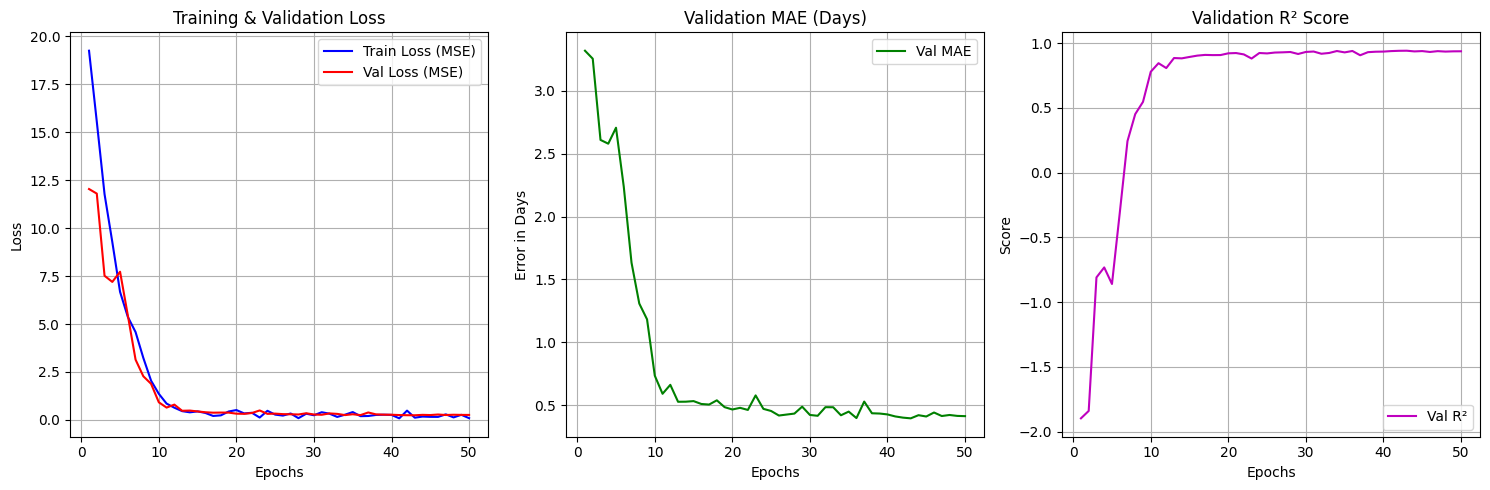

In [56]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(15, 5))

    # Plot 1: MSE Loss (Train vs Val)
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss (MSE)')
    plt.plot(epochs, history['val_mse'], 'r-', label='Val Loss (MSE)')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot 2: MAE (Mean Absolute Error)
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['val_mae'], 'g-', label='Val MAE')
    plt.title('Validation MAE (Days)')
    plt.xlabel('Epochs')
    plt.ylabel('Error in Days')
    plt.legend()
    plt.grid(True)

    # Plot 3: R² Score
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['val_r2'], 'm-', label='Val R²')
    plt.title('Validation R² Score')
    plt.xlabel('Epochs')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Run the plot
plot_training_history(history)

In [57]:
# 1. Initialize the model architecture again (or use the existing one)
model.load_state_dict(torch.load('best_banana_model.pth'))
model.to(device)
def test_loop(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    total_mae = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels) # This is your MSE

            running_loss += loss.item()
            total_mae += torch.abs(outputs - labels).sum().item()

            # Collect all for R2 calculation
            all_preds.extend(outputs.view(-1).cpu().tolist())
            all_labels.extend(labels.view(-1).cpu().tolist())

    # Metrics Calculation
    avg_mse = running_loss / len(loader)
    avg_mae = total_mae / len(loader.dataset)

    # Coefficient of Determination (R2 Score)
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2_score = 1 - (ss_res / ss_tot)

    return avg_mse, avg_mae, r2_score

# Run evaluation
mse, mae, r2 = test_loop(model, test_loader, criterion, device)

print(f"Test Results:")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f} days")
print(f"R² Score: {r2:.4f}")

Test Results:
MSE: 1.4031
MAE: 0.9079 days
R² Score: 0.7228


In [ ]:
def plot_regression_results(all_labels, all_preds):
    plt.figure(figsize=(8, 8))
    plt.scatter(all_labels, all_preds, alpha=0.5, color='blue')
    
    # Draw the "Perfect Prediction" line
    max_val = max(max(all_labels), max(all_preds))
    plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')
    
    plt.xlabel('Actual Ripeness (Days)')
    plt.ylabel('Predicted Ripeness (Days)')
    plt.title(f'Actual vs. Predicted (R²: {val_r2:.4f})')
    plt.grid(True)
    plt.show()

# Use the lists from your last val_loop
plot_regression_results(all_labels, all_preds)

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def visualize_test_results(model, test_dataset, device, num_images=5):
    model.eval()
    indices = random.sample(range(len(test_dataset)), num_images)
    
    plt.figure(figsize=(20, 4))
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, label = test_dataset[idx]
            image_tensor = image.unsqueeze(0).to(device)
            
            # Get Prediction
            output = model(image_tensor)
            prediction = output.item()
            actual = label.item()
            
            # Convert tensor back to image for display
            # Undo normalization for viewing
            inv_normalize = transforms.Normalize(
                mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
                std=[1/0.229, 1/0.224, 1/0.225]
            )
            display_img = inv_normalize(image).permute(1, 2, 0).cpu().numpy()
            display_img = np.clip(display_img, 0, 1)

            # Plotting
            plt.subplot(1, num_images, i + 1)
            plt.imshow(display_img)
            
            error = abs(prediction - actual)
            color = "green" if error <= 1.0 else "red"
            
            plt.title(f"Actual: {actual:.1f}d\nPred: {prediction:.1f}d", 
                      color=color, fontweight='bold')
            plt.axis('off')
            
    plt.show()

# Run it!
visualize_test_results(model, test_data, device)